
### **Student Name**: Amey Vivek Khodke

# Importing Required Libraries

In [40]:
import pandas as pd
import numpy as np
import seaborn as sns

In [41]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, root_mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score

# Loading Dataset and understanding Features

In [42]:
# Loading the Dataset and Understanding the columns of the Dataset
df = pd.read_csv('tesla_deliveries_dataset_2015_2025.csv')

# Dataset shape
print(df.shape)

# Dataset info
print('\n Dataset Information')
df.info()

# Dataset Description
print('\n Dataset Description')
display(df.describe())

# Dataset first 10 rows 
print('First 10 rows of the Dataset')
df.head(10)

(2640, 12)

 Dataset Information
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2640 entries, 0 to 2639
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Year                  2640 non-null   int64  
 1   Month                 2640 non-null   int64  
 2   Region                2640 non-null   object 
 3   Model                 2640 non-null   object 
 4   Estimated_Deliveries  2640 non-null   int64  
 5   Production_Units      2640 non-null   int64  
 6   Avg_Price_USD         2640 non-null   float64
 7   Battery_Capacity_kWh  2640 non-null   int64  
 8   Range_km              2640 non-null   int64  
 9   CO2_Saved_tons        2640 non-null   float64
 10  Source_Type           2640 non-null   object 
 11  Charging_Stations     2640 non-null   int64  
dtypes: float64(2), int64(7), object(3)
memory usage: 247.6+ KB

 Dataset Description


,Year,Month,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Charging_Stations
count,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000,2640.000000
mean,2020.000000,6.500000,9922.199621,10655.847348,84907.340330,87.059470,500.257576,744.076989,8932.133712
std,3.162877,3.452707,3935.950093,4260.600858,20123.258036,20.836265,120.868549,353.221224,3469.565883
min,2015.000000,1.000000,48.000000,50.000000,50003.700000,60.000000,330.000000,3.070000,3002.000000
25%,2017.000000,3.750000,7292.000000,7828.250000,67726.365000,75.000000,418.000000,499.620000,5897.750000
50%,2020.000000,6.500000,9857.000000,10546.500000,85058.510000,82.000000,470.000000,699.515000,8901.500000
75%,2023.000000,9.250000,12510.250000,13469.000000,102373.042500,100.000000,586.250000,943.765000,11938.000000
max,2025.000000,12.000000,25704.000000,28939.000000,119965.360000,120.000000,719.000000,2548.550000,14996.000000


First 10 rows of the Dataset


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,Europe,Model S,17646,17922,92874.27,120,704,1863.42,Interpolated (Month),12207
1,2015,2,Asia,Model X,3797,4164,62205.65,75,438,249.46,Official (Quarter),7640
2,2019,1,North America,Model X,8411,9189,117887.32,82,480,605.59,Interpolated (Month),14071
3,2021,2,North America,Model 3,6555,7311,89294.91,120,712,700.07,Official (Quarter),9333
4,2016,12,Middle East,Model Y,12374,13537,114846.78,120,661,1226.88,Estimated (Region),8722
5,2020,4,Asia,Model X,4656,5043,86930.57,82,477,333.14,Official (Quarter),5798
6,2015,11,Asia,Model 3,7717,7976,87588.21,82,475,549.84,Interpolated (Month),9961
7,2020,6,Europe,Cybertruck,8410,9192,73815.61,100,592,746.81,Official (Quarter),8216
8,2022,4,Europe,Model S,15145,15760,69993.86,100,563,1279.00,Interpolated (Month),13264
9,2021,3,Middle East,Model Y,7790,8208,50591.60,82,485,566.72,Interpolated (Month),3383


# Handling missing values and Duplicates 

In [43]:
# Checking Missing values in the Dataset
print('Missing values Summary of the Dataset: ')
display(df.isnull().sum())

# checking Duplicates in the Dataset
duplicate_values = df.duplicated().sum()
print('Duplicates in the Dataset: ',duplicate_values)

# if duplicate values are present in the dataset then delete the duplicate values
if duplicate_values == 0:
    print('There are no duplicates in the dataset. All values are unique')
else:
    df.drop_duplicates(inplace=True)
    df.reset_index(drop=True, inplace=True)
    print('After deleting the values the new shape of the Dataset is: ',df.shape)

# Making the Date Feature - It is required for the various purposes as for the time series and other things
df['Date'] = pd.to_datetime(dict(year=df.Year,month=df.Month,day=1))

Missing values Summary of the Dataset: 


Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64

Duplicates in the Dataset:  0
There are no duplicates in the dataset. All values are unique


# Exploratory Data Analysis (EDA)

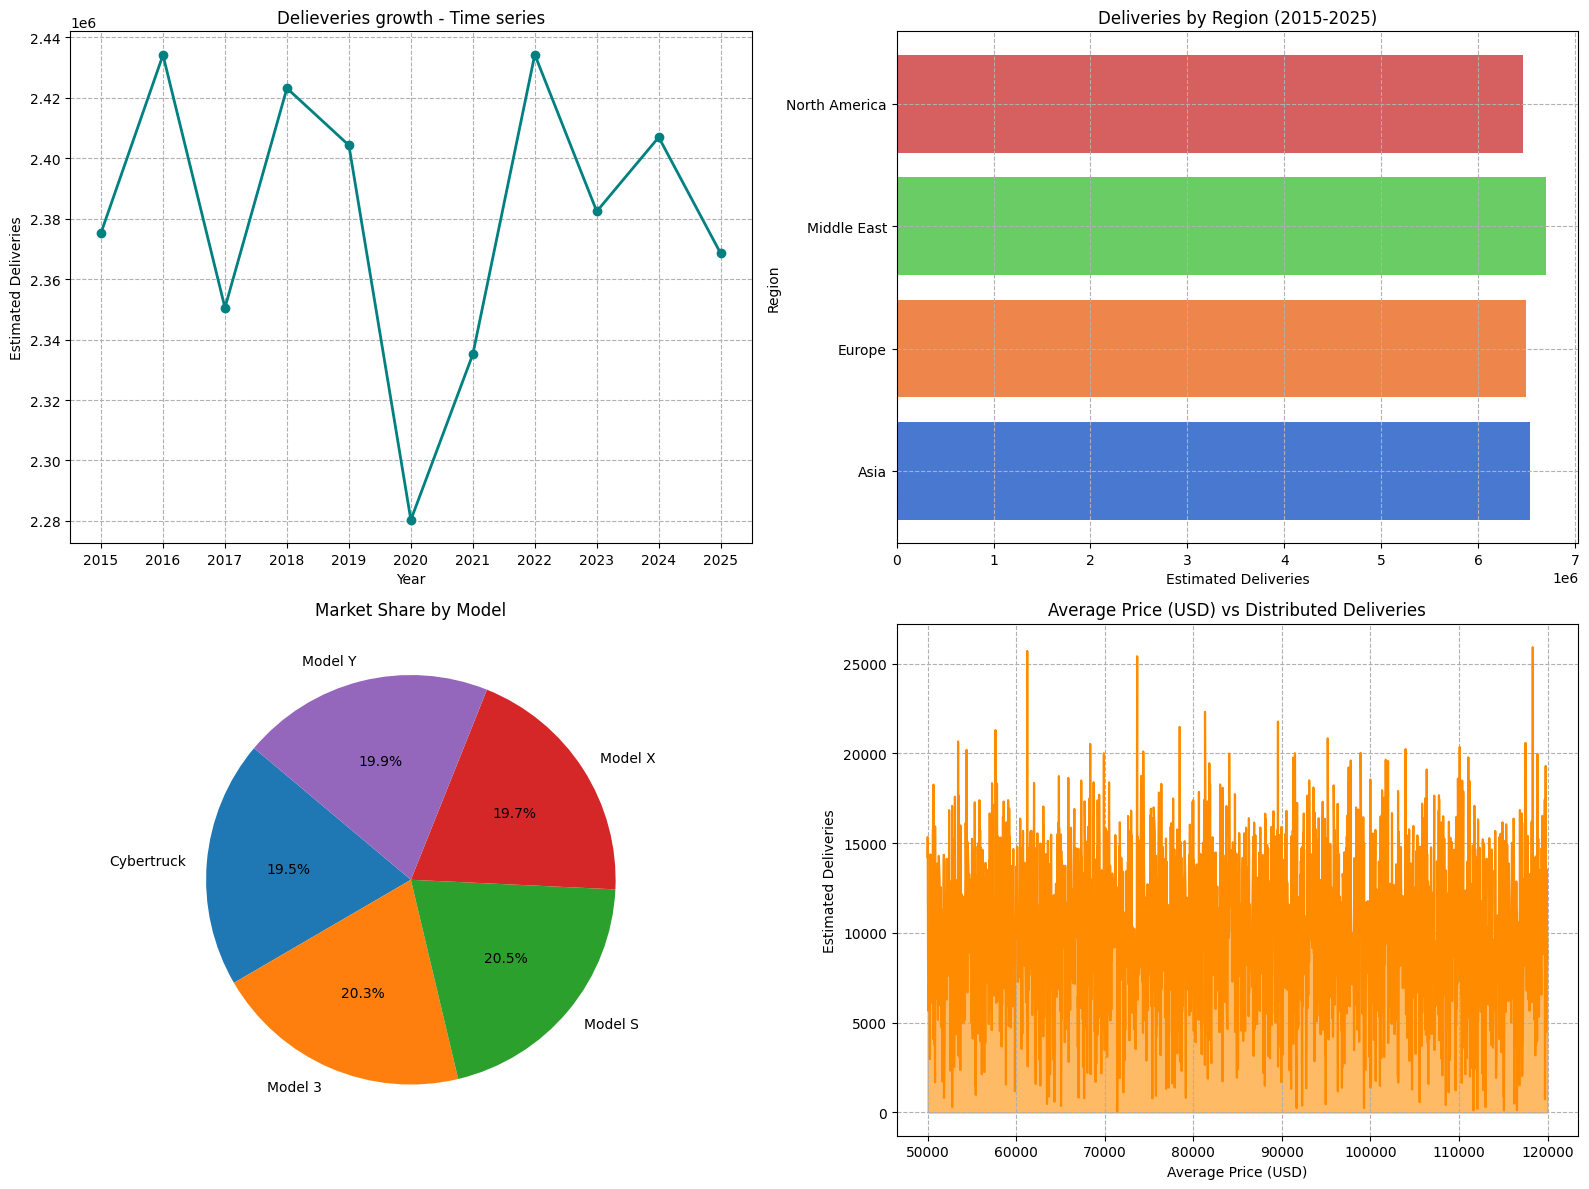

In [44]:
# Performing Exploratory Data Analysis
import matplotlib.pyplot as plt

# Subplots : Global Performance and Market Performance Analysis
fig1, graph = plt.subplots(2,2,figsize=(16,12))

# Chart 1: Yearly Trend (Time series plot chart)
df_yearly = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()
graph[0,0].plot(df_yearly['Year'],df_yearly['Estimated_Deliveries'], marker='o',color='teal', linewidth=2)
graph[0,0].set_title('Delieveries growth - Time series')
graph[0,0].set_xlabel('Year')
graph[0,0].set_xticks(range(2015,2026))
graph[0,0].set_ylabel('Estimated Deliveries')
graph[0,0].grid(True, linestyle='--')

# Chart 2: Regional Performance (Bar chart)
df_region = df.groupby('Region')['Estimated_Deliveries'].sum().reset_index()
graph[0,1].barh(df_region['Region'],df_region['Estimated_Deliveries'], color=sns.color_palette('muted',len(df_region)))
graph[0,1].set_title('Deliveries by Region (2015-2025)')
graph[0,1].set_ylabel('Region')
graph[0,1].set_xlabel('Estimated Deliveries')
graph[0,1].grid(True, linestyle='--')

# Chart 3: Model Performance (Pie chart)
df_model = df.groupby('Model')['Estimated_Deliveries'].sum().reset_index()
graph[1, 0].pie(df_model['Estimated_Deliveries'], labels=df_model['Model'], autopct='%1.1f%%', startangle=140)
graph[1, 0].set_title('Market Share by Model')

# Chart 4: Average price vs Distributed Deliveries (Area chart)
df_avg = df.groupby('Avg_Price_USD')['Estimated_Deliveries'].sum().reset_index()
graph[1,1].fill_between(df_avg['Avg_Price_USD'],df_avg['Estimated_Deliveries'], color='darkorange', alpha=0.6)
graph[1,1].plot(df_avg['Avg_Price_USD'], df_avg['Estimated_Deliveries'], color='darkorange', linewidth=1.5)
graph[1,1].set_title('Average Price (USD) vs Distributed Deliveries')
graph[1,1].set_xlabel('Average Price (USD)')
graph[1,1].set_ylabel('Estimated Deliveries')
graph[1,1].grid(True, linestyle='--')

plt.tight_layout()
plt.show()

# Feature Engineering

In [45]:
# Feature Engineering
le = LabelEncoder()

# Convert Categorical values to the Numerical by LabelEncoding
df['Region'] = le.fit_transform(df['Region'])
df['Model'] = le.fit_transform(df['Model'])
df['Source_Type'] = le.fit_transform(df['Source_Type'])

# Making the New Features that are important from the raw data

# First feature : Quarter - It tells us that production distribution per month
df['Quarter'] = df['Date'].dt.quarter

# Second Feature: co2_saved_per_unit - It tells that how much co2 is saved from production units
df['co2_saved_per_unit'] = df['CO2_Saved_tons'] / (df['Production_Units'] + 1e-5)

# Third Feature: production efficiency - It checks the production efficiency by estimated deliverables
df['Production_efficiency'] = df['Estimated_Deliveries'] / df['Production_Units']

# Fourth Feature: price_per_km
df['price_per_km'] = df['Avg_Price_USD'] / df['Range_km']

df.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations,Date,Quarter,co2_saved_per_unit,Production_efficiency,price_per_km
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207,2023-05-01,2,0.103974,0.984600,131.923679
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640,2015-02-01,1,0.059909,0.911864,142.022032
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071,2019-01-01,1,0.065904,0.915334,245.598583
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333,2021-02-01,1,0.095756,0.896594,125.414199
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722,2016-12-01,4,0.090632,0.914087,173.747020


# Chronological Train-Test Split

In [46]:
# Chronological sort Train Test split
df = df.sort_values(by='Date').reset_index(drop=True)

# Splitting the data into X and y
X = df.drop(columns=['Estimated_Deliveries','Date'])
y = df['Estimated_Deliveries']

split_index = int(len(df) * 0.8)

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print('Train Set size: ',X_train.shape[0])
print('Test set size: ',X_test.shape[0])
print(f"Training Data Timeline: {df['Date'].iloc[0].strftime('%Y-%m')} to {df['Date'].iloc[split_index-1].strftime('%Y-%m')}")
print(f"Testing Data Timeline: {df['Date'].iloc[split_index].strftime('%Y-%m')} to {df['Date'].iloc[-1].strftime('%Y-%m')}")

Train Set size:  2112
Test set size:  528
Training Data Timeline: 2015-01 to 2023-10
Testing Data Timeline: 2023-10 to 2025-12


# Linear Regression (Model Training)

Mean Absolute Error (MAE):  106.13088711874289
Mean Squared Error (MAE):  22829.871028247035
Root Mean squared Error (MAE):  151.09556918800445
R2 Score:  0.9982828916462172


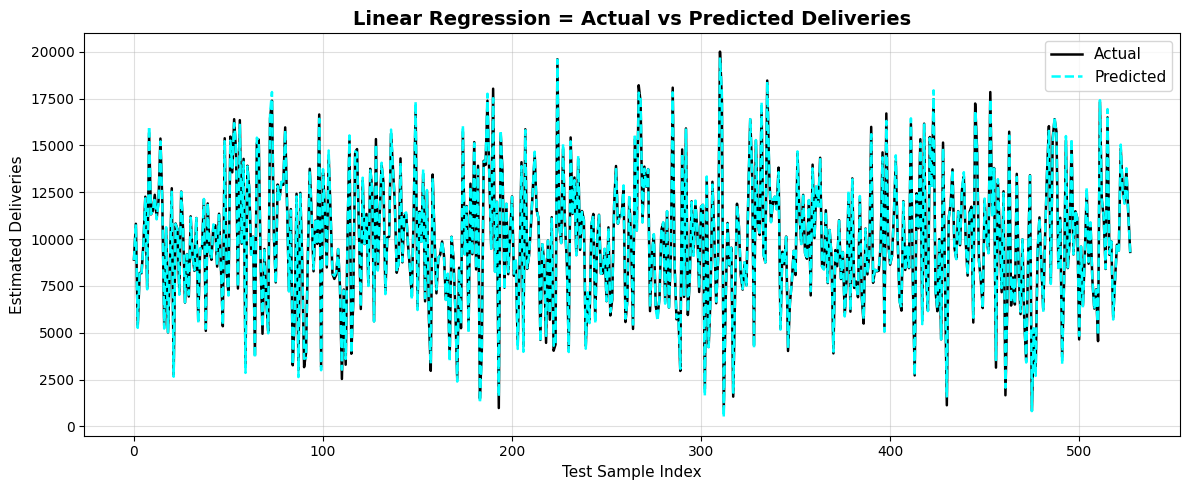

In [47]:
# Model Initialization and Training
model = LinearRegression()
model.fit(X_train, y_train)

# Making Predictions
y_pred = model.predict(X_test)

# Calculating the Metrics
print('Mean Absolute Error (MAE): ',mean_absolute_error(y_test,y_pred))
print('Mean Squared Error (MAE): ',mean_squared_error(y_test,y_pred))
print('Root Mean squared Error (MAE): ',root_mean_squared_error(y_test,y_pred))
print('R2 Score: ',r2_score(y_test,y_pred))

# Plotting - acutal vs Predicted
fig, ax = plt.subplots(figsize=(12, 5))

test_indices = np.arange(len(y_test))
ax.plot(test_indices, y_test,    label='Actual',    color='black',  linewidth=1.8)
ax.plot(test_indices, y_pred, label='Predicted', color='cyan', linewidth=1.8, linestyle='--')

ax.set_title('Linear Regression = Actual vs Predicted Deliveries', fontsize=14, fontweight='bold')
ax.set_xlabel('Test Sample Index', fontsize=11)
ax.set_ylabel('Estimated Deliveries', fontsize=11)
ax.legend(fontsize=11)
ax.grid(alpha=0.4)

plt.tight_layout()
plt.show()

# Cross Validation

In [48]:
# Cross validation Performance
scores = cross_val_score(model, X, y, cv=5, scoring='r2')

print('K Fold Cross validation - Linear Regression\n')

for i,s in enumerate(scores,1):
    print(f'Fold {i}: R2: {s:.4f}')

print(f'\nMean R squared: {scores.mean():.4f}')
print(f'Standard Deviation: {scores.std():.4f}')

# Defining the threshold
if scores.std() < 0.05:
    print('\nThe model is performing well in all the folds ')
else:
    print('\nThere is some variance in across fields')

K Fold Cross validation - Linear Regression

Fold 1: R2: 0.9983
Fold 2: R2: 0.9984
Fold 3: R2: 0.9986
Fold 4: R2: 0.9985
Fold 5: R2: 0.9983

Mean R squared: 0.9984
Standard Deviation: 0.0001

The model is performing well in all the folds 


# Hyperparameter Tuning (Ridge and Lasso)

In [49]:
# Hyperparameter Tuning (Ridge and Lasso)

# importing libraries
from sklearn.linear_model import Ridge, Lasso
from sklearn.model_selection import GridSearchCV

# As there is only one Hyperparameter : alpha
param_grid = {
    'alpha':[0.01,0.1,1,10,100]
}

# Ridge Fine tuning
ridge = Ridge()
cv_r = GridSearchCV(ridge, param_grid, cv=5, scoring='r2')
cv_r.fit(X_train, y_train)
print('Best Ridge Alpha: ', cv_r.best_params_)

# Lasso Fine tuning
lasso = Lasso()
cv_lasso = GridSearchCV(lasso, param_grid, cv=5, scoring='r2')
cv_lasso.fit(X_train, y_train)
print('Best Lasso Alpha: ', cv_lasso.best_params_)

# Evaluating
best_r = cv_r.best_estimator_
best_lasso = cv_lasso.best_estimator_

ridge_pred = best_r.predict(X_test)
lasso_pred = best_lasso.predict(X_test)

print('Ridge R2 Score: ', r2_score(y_test,ridge_pred))
print('Lasso R2 Score: ', r2_score(y_test, lasso_pred))


Best Ridge Alpha:  {'alpha': 0.01}
Best Lasso Alpha:  {'alpha': 0.01}
Ridge R2 Score:  0.9982858828491555
Lasso R2 Score:  0.9982865851809686


# Stationarity Testing (on Target Column)

In [50]:
!pip install statsmodels


[notice] A new release of pip is available: 24.0 -> 26.1.2
[notice] To update, run: C:\Users\ameyk\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [51]:
# Stationarity Testing
from statsmodels.tsa.stattools import adfuller

result = adfuller(df['Estimated_Deliveries'].dropna(), autolag='AIC')

stat = result[0]
pvalue = result[1]
critical = result[4]

print('Augmented Dickey fuller Test \n')
print('Column Tested: Estimated_Deliverables')
print(f'Statistics: {stat:.4f}')
print(f'p value: {pvalue:.4f}')
print('Critical Values: ')
for key,val in critical.items():
    print(f'{key}:{val:.4f}')

if pvalue < 0.05:
    print('The Time series is stationary')
else:
    print('Time series is not stationary')

Augmented Dickey fuller Test 

Column Tested: Estimated_Deliverables
Statistics: -28.1762
p value: 0.0000
Critical Values: 
1%:-3.4328
5%:-2.8626
10%:-2.5674
The Time series is stationary


# Time Series Forecasting

ADF Statistic: -8.796891845702463
p-value: 2.1642553612092046e-14
Series is Stationary


C:\Users\ameyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ameyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ameyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ameyk\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\Local

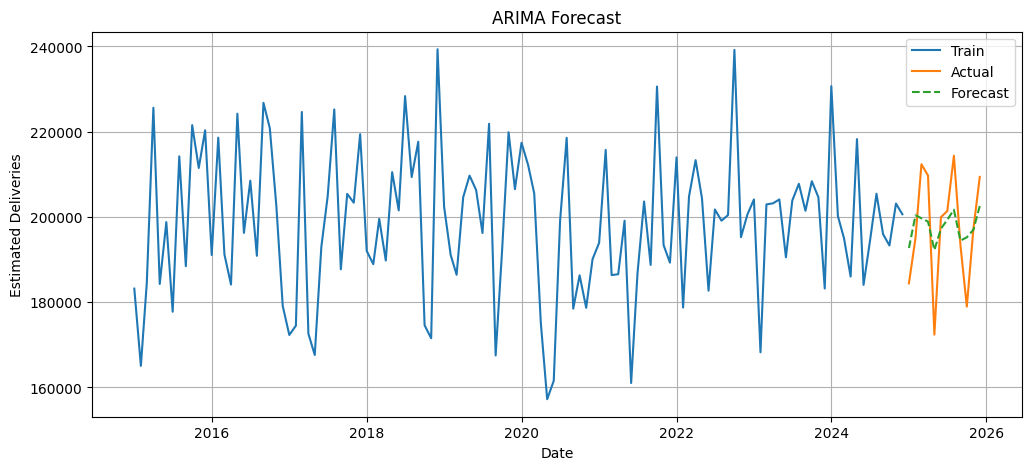

Mean Absolute Error 8229.671680974576
Mean Squared Error 104498553.78706895
Root Mean Squared Error 10222.453413299028
R2 Score:  0.36861701961184345


In [52]:
from statsmodels.tsa.arima.model import ARIMA

# Monthly deliveries
ts = df.groupby('Date')['Estimated_Deliveries'].sum()

# Log transformation
ts_log = np.log(ts)

# Check stationarity
result = adfuller(ts_log)
print("ADF Statistic:", result[0])
print("p-value:", result[1])

if result[1] < 0.05:
    print("Series is Stationary")
else:
    print("Series is Not Stationary")

# Train-Test Split
train = ts_log[:-12]
test = ts_log[-12:]

# ARIMA Model
model = ARIMA(train, order=(4,0,5))
fit = model.fit()

# Forecast
forecast_log = fit.forecast(steps=len(test))

# Convert back to original values
forecast = np.exp(forecast_log)
actual = np.exp(test)

# Plot
plt.figure(figsize=(12,5))
plt.plot(train.index, np.exp(train), label='Train')
plt.plot(test.index, actual, label='Actual')
plt.plot(test.index, forecast, '--', label='Forecast')
plt.title("ARIMA Forecast")
plt.xlabel("Date")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)
plt.show()

# Evaluation Metrics
print('Mean Absolute Error', mean_absolute_error(actual,forecast))
print('Mean Squared Error', mean_squared_error(actual,forecast))
print('Root Mean Squared Error', np.sqrt(mean_squared_error(actual,forecast)))
print('R2 Score: ', r2_score(actual,forecast))

## Conclusion

- Completed preprocessing and data cleaning.
- Performed EDA to identify trends and correlations.
- Engineered new predictive features.
- Built Linear Regression Ridge and Lasso models.
- Improved performance using hyperparameter tuning.
- Forecasted future Tesla deliveries using Holt-Winters Exponential Smoothing.
- Summarized business insights from regression and forecasting results.